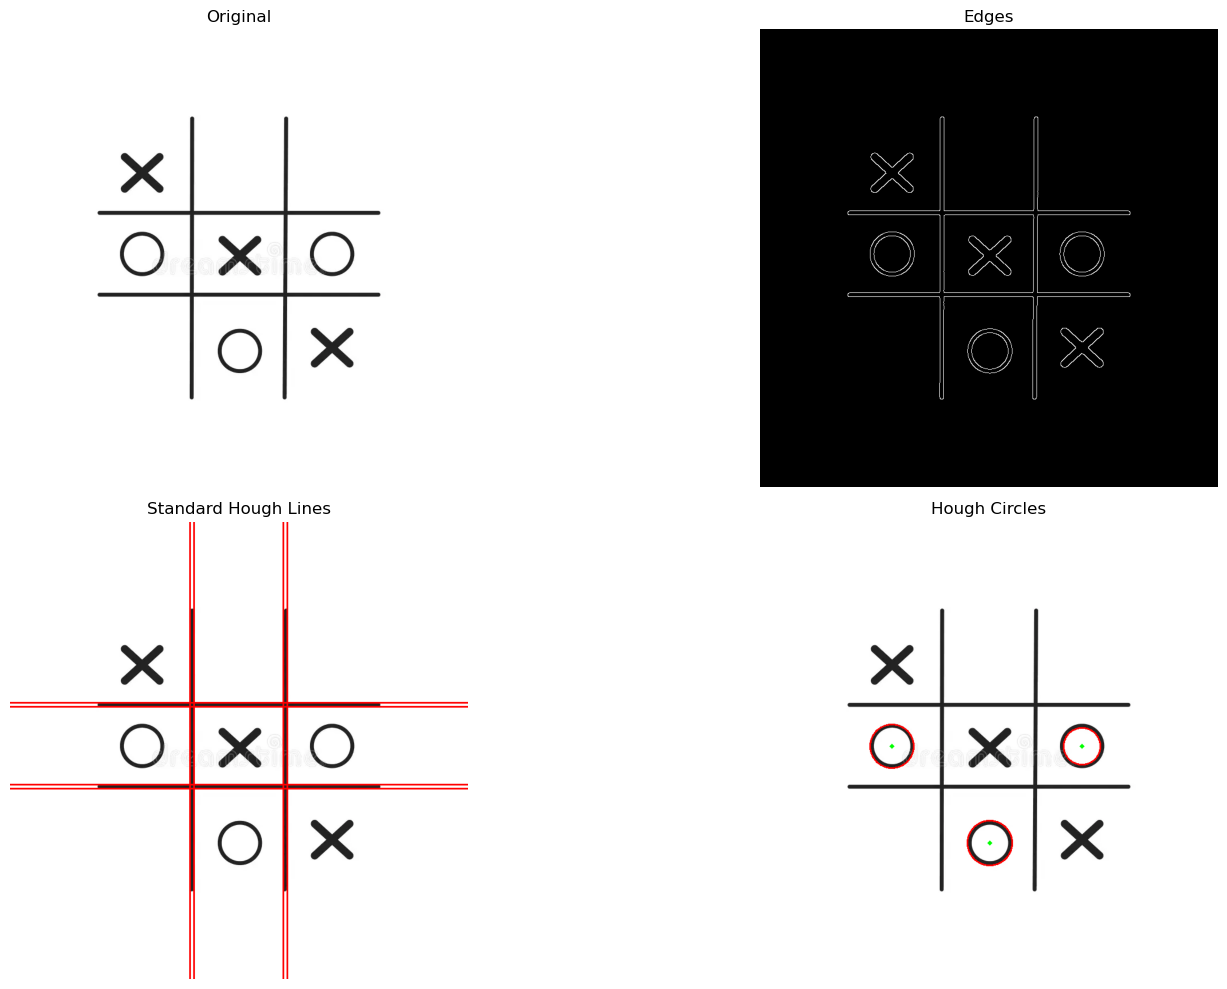

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "game.webp"
img_bgr = cv2.imread(image_path)

if img_bgr is None:
    raise FileNotFoundError(f"Could not load image: {image_path}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (5, 5), 0)

edges = cv2.Canny(blurred, 50, 150)

# Hough Lines
line_img = img_rgb.copy()
lines = cv2.HoughLines(edges, 1, np.pi / 180, 150)

if lines is not None:
    for line in lines[:20]:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho

        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))

        cv2.line(line_img, (x1, y1), (x2, y2), (255, 0, 0), 2)


# Circle 
circle_img = img_rgb.copy()
circles = cv2.HoughCircles(
    blurred,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=80,      
    param1=120,   
    param2=90,      
    minRadius=20,
    maxRadius=60
)


if circles is not None:
    circles = np.round(circles[0, :]).astype("int")
    for (x, y, r) in circles:
        cv2.circle(circle_img, (x, y), r, (255, 0, 0), 2)
        cv2.circle(circle_img, (x, y), 2, (0, 255, 0), 3)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")


axes[0, 1].imshow(edges, cmap="gray")
axes[0, 1].set_title("Edges")
axes[0, 1].axis("off")

axes[1, 0].imshow(line_img)
axes[1, 0].set_title("Standard Hough Lines")
axes[1, 0].axis("off")


axes[1, 1].imshow(circle_img)
axes[1, 1].set_title("Hough Circles")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

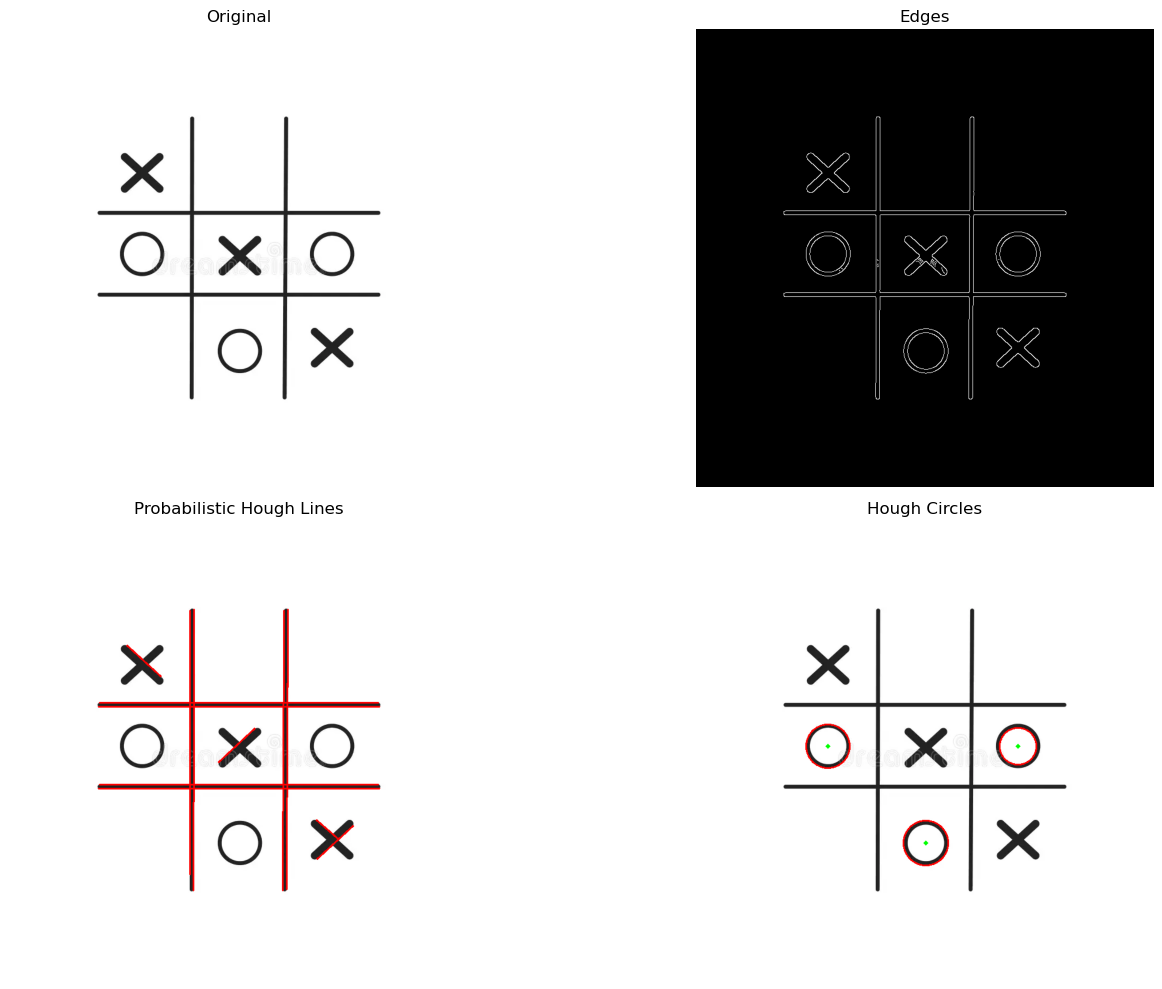